In [4]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import classification_report,confusion_matrix

In [5]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
print("Training data shape:",x_train.shape)
print("Training labels shape:",y_train.shape)
print("Testing data shape:",x_test.shape)
print("testing labels shape:",y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
testing labels shape: (10000,)


In [8]:
plt.figure(figsize=(8,8))
           

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

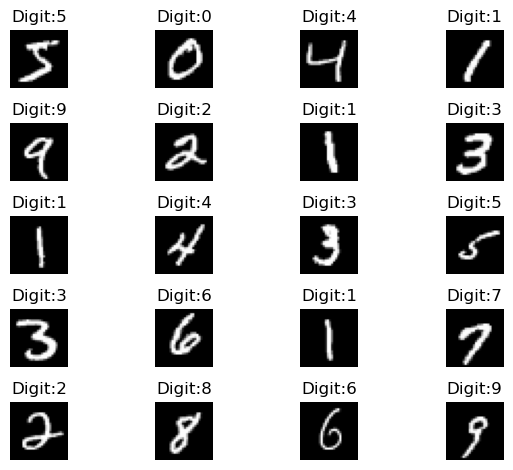

In [13]:
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.imshow(x_train[i],cmap="gray")
    plt.title("Digit:"+str(y_train[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()
  

In [17]:
x_train=x_train.reshape(x_train.shape[0],784).astype("float32")
x_test=x_test.reshape(x_test.shape[0],784).astype("float32")

In [18]:
x_train=x_train/255.0
x_test=x_test/255.0

In [19]:
print("After preprocessing;")
print("Training data shape:",x_train.shape)
print("Testing data shape:",x_test.shape)

After preprocessing;
Training data shape: (60000, 784)
Testing data shape: (10000, 784)


In [24]:
model=Sequential([
    Input(shape=(784,)),
    Dense(64,activation="sigmoid"),
    Dense(10,activation="softmax")
])

In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer=SGD(learning_rate=0.3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
history=model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8348 - loss: 0.6679 - val_accuracy: 0.9185 - val_loss: 0.3116
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9055 - loss: 0.3335 - val_accuracy: 0.9318 - val_loss: 0.2486
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9185 - loss: 0.2849 - val_accuracy: 0.9385 - val_loss: 0.2213
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9267 - loss: 0.2555 - val_accuracy: 0.9457 - val_loss: 0.2009
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9333 - loss: 0.2337 - val_accuracy: 0.9522 - val_loss: 0.1827
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9380 - loss: 0.2160 - val_accuracy: 0.9542 - val_loss: 0.1730
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9423 - loss: 0.2007 - val_accuracy: 0.9593 - val_loss: 0.1615
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9459 - loss: 0.1879 - val_accuracy: 0.

In [28]:
test_loss,test_accuracy=model.evaluate(
    x_test,
    y_test,
    verbose=0
)

In [29]:
print("\nTest Loss:",test_loss)
print("Test Accuracy;",test_accuracy)


Test Loss: 0.11975141614675522
Test Accuracy; 0.963699996471405


In [30]:
y_probability=model.predict(x_test,verbose=0)

In [31]:
y_pred=np.argmax(y_probability,axis=1)


In [32]:
cm=confusion_matrix(y_test,y_pred)

In [33]:
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[ 969    0    1    1    0    3    3    2    1    0]
 [   0 1119    3    1    0    1    4    2    5    0]
 [   9    1  991    4    5    3    7    6    5    1]
 [   2    1    6  976    1    6    1    9    6    2]
 [   1    0    6    1  939    2    3    3    2   25]
 [   7    1    2   15    2  846    6    3    7    3]
 [  10    3    0    0    2   10  925    2    6    0]
 [   2    7   15    4    1    1    0  990    0    8]
 [   5    2    2   10    4    8    8    7  927    1]
 [   6    6    0   10   15    5    0    8    4  955]]


In [34]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       980
           1       0.98      0.99      0.98      1135
           2       0.97      0.96      0.96      1032
           3       0.95      0.97      0.96      1010
           4       0.97      0.96      0.96       982
           5       0.96      0.95      0.95       892
           6       0.97      0.97      0.97       958
           7       0.96      0.96      0.96      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [35]:
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

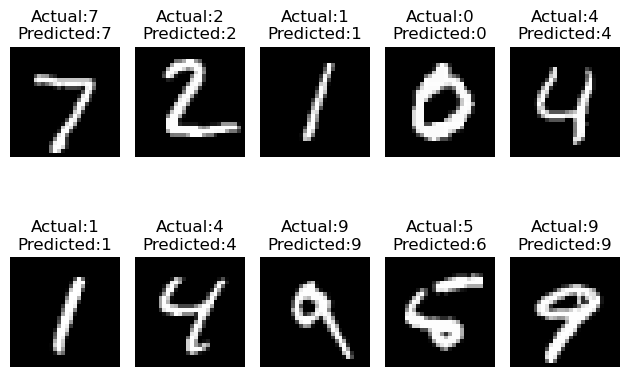

In [36]:
for i in range(10):
    plt.subplot(2,5,i+1)
    image=x_test[i].reshape(28,28)
    plt.imshow(image,cmap="gray")
    plt.title(
    "Actual:"+str(y_test[i])+
    "\nPredicted:"+str(y_pred[i])
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
kMEA2123
